# 14 — Threshold, Curva de Decisão e Cenários de Custo

## Objetivo

Comparar explicitamente a curva de decisão de dois cenários já aprovados para investigação:

1. `referencia_24h_ids_textual`: gap 900s, observação 24h, horizonte 8h, IDs + conceitos textuais;
2. `multijanela_core_ids_textual`: mesma configuração temporal, mas features gerais separadas em
   buckets 0-8h, 8-16h e 16-24h.

## Pergunta

Para thresholds escolhidos na validação, qual é a troca entre recall, falsos positivos, falsos
negativos e valor esperado sob premissas econômicas explícitas?

## Limites de interpretação

- `Is_Dont_Go` continua sendo uma flag entregue, não falha confirmada.
- Os custos deste notebook são **premissas externas de cenário**, não valores observados nos dados da
  Vale.
- Qualquer valor econômico deve ser lido como sensibilidade. Não é ROI real.
- Thresholds são avaliados na validação e só depois aplicados ao teste.
- O teste não decide parâmetros; ele audita a consequência de escolhas feitas na validação.

In [1]:
from pathlib import Path
import re
import time
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score, fbeta_score,
    precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 250)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

GAP_S = 900
OBSERVATION_HOURS = 24
HORIZON_HOURS = 8
BUCKET_HOURS = 8
TOP_ALARM_IDS = 200
TOP_TEXT_CONCEPTS = 200

LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)
MISSING_START = pd.Timestamp("2025-05-31 00:00:00")
MISSING_END = pd.Timestamp("2025-06-01 00:00:00")

THRESHOLD_GRID = np.round(np.linspace(0.01, 0.99, 197), 3)

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

def normalize_alarm_name(value):
    if pd.isna(value):
        return "SEM_DESCRICAO"
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or "SEM_DESCRICAO"

print(f"Raiz do projeto: {ROOT}")
print(f"Configuração: gap={GAP_S}s, observação={OBSERVATION_HOURS}h, horizonte={HORIZON_HOURS}h")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Configuração: gap=900s, observação=24h, horizonte=8h


## 1. Premissas econômicas de cenário auditáveis

Estes valores **não vêm dos dados brutos**. Eles existem para avaliar sensibilidade da decisão.

As fontes e limites estão registrados em `docs/PREMISSAS_ECONOMICAS_EXTERNAS.md`.

Campos:

- `p_acao_confirmada`: fração assumida dos episódios `Is_Dont_Go` que virariam evento operacional
  acionável. Como o target não é falha confirmada, este fator precisa existir.
- `custo_intervencao_preditiva`: custo de inspecionar/intervir após predição positiva.
- `custo_manutencao_corretiva`: custo de manutenção quando o evento acionável não foi prevenido.
- `impacto_operacional_hora`: perda operacional por hora de equipamento parado.
- `horas_parada_corretiva`: parada média corretiva assumida.
- `horas_parada_preditiva`: parada média planejada assumida.

Substituir estes valores por dados reais da operação quando existirem. Enquanto isso, a decisão
econômica é apenas uma análise de cenário.

In [2]:
economic_base = pd.DataFrame([
    {
        "Tipo": "Caminhao",
        "cenario_custo": "base_empirico_manutencao_8h",
        "p_acao_confirmada": 0.655,
        "custo_intervencao_preditiva": 10000.0,
        "custo_manutencao_corretiva": 50000.0,
        "impacto_operacional_hora": 30000.0,
        "horas_parada_corretiva": 4.0,
        "horas_parada_preditiva": 1.0,
        "nivel_confianca": "media",
        "base_premissa": "p observado no treino: Dont Go -> Manutenção em 8h; custos de fontes públicas/ordem de grandeza",
    },
    {
        "Tipo": "Escavadeira",
        "cenario_custo": "base_empirico_manutencao_8h",
        "p_acao_confirmada": 0.20,
        "custo_intervencao_preditiva": 25000.0,
        "custo_manutencao_corretiva": 150000.0,
        "impacto_operacional_hora": 100000.0,
        "horas_parada_corretiva": 8.0,
        "horas_parada_preditiva": 2.0,
        "nivel_confianca": "baixa",
        "base_premissa": "p conservador por poucos episódios Dont Go; custos de fontes públicas/extrapolação operacional",
    },
])

sensitivity_rows = []
for _, row in economic_base.iterrows():
    for multiplier in [0.5, 1.0, 2.0]:
        for p_actionable in [0.05, 0.10, 0.20, 0.40]:
            new = row.copy()
            new["cenario_custo"] = f"impacto_x{multiplier:g}_p{p_actionable:g}"
            new["impacto_operacional_hora"] = row["impacto_operacional_hora"] * multiplier
            new["custo_manutencao_corretiva"] = row["custo_manutencao_corretiva"] * multiplier
            new["p_acao_confirmada"] = p_actionable
            sensitivity_rows.append(new)
economic_sensitivity = pd.DataFrame(sensitivity_rows)

display(economic_base)
display(economic_sensitivity.head(12))

,Tipo,cenario_custo,p_acao_confirmada,custo_intervencao_preditiva,custo_manutencao_corretiva,impacto_operacional_hora,horas_parada_corretiva,horas_parada_preditiva,nivel_confianca,base_premissa
0,Caminhao,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
1,Escavadeira,base_empirico_manutencao_8h,0.200,25000.0,150000.0,100000.0,8.0,2.0,baixa,p conservador por poucos episódios Dont Go; cu...


,Tipo,cenario_custo,p_acao_confirmada,custo_intervencao_preditiva,custo_manutencao_corretiva,impacto_operacional_hora,horas_parada_corretiva,horas_parada_preditiva,nivel_confianca,base_premissa
0,Caminhao,impacto_x0.5_p0.05,0.05,10000.0,25000.0,15000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
0,Caminhao,impacto_x0.5_p0.1,0.10,10000.0,25000.0,15000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
0,Caminhao,impacto_x0.5_p0.2,0.20,10000.0,25000.0,15000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
0,Caminhao,impacto_x0.5_p0.4,0.40,10000.0,25000.0,15000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
0,Caminhao,impacto_x1_p0.05,0.05,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
0,Caminhao,impacto_x1_p0.1,0.10,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
0,Caminhao,impacto_x1_p0.2,0.20,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
0,Caminhao,impacto_x1_p0.4,0.40,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
0,Caminhao,impacto_x2_p0.05,0.05,10000.0,100000.0,60000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...
0,Caminhao,impacto_x2_p0.1,0.10,10000.0,100000.0,60000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...


## 2. Camada analítica congelada

In [3]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

base_audit = query(
    '''
    SELECT
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo - 1) AS duplicatas_retiradas,
        sum(Is_Dont_Go) AS linhas_dont_go,
        count(DISTINCT TAG) AS tags
    FROM analytic_events
    '''
)
base_audit["tempo_s"] = round(time.time() - start, 1)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,tags,tempo_s
0,35608094,265564.0,19941.0,35,15.3


## 3. Sequências, amostras e features

In [4]:
def build_sequences():
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_sequences AS
        WITH ordered AS (
            SELECT *,
                   lag(Data_Evento) OVER (
                       PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ) AS evento_anterior
            FROM analytic_events
        ), flagged AS (
            SELECT *,
                   CASE
                       WHEN evento_anterior IS NULL THEN 1
                       WHEN date_diff('millisecond', evento_anterior, Data_Evento) > {GAP_S * 1000} THEN 1
                       ELSE 0
                   END AS nova_sequencia
            FROM ordered
        ), numbered AS (
            SELECT *,
                   sum(nova_sequencia) OVER (
                       PARTITION BY TAG, Id_Alarme
                       ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                       ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                   ) AS numero_sequencia
            FROM flagged
        )
        SELECT
            TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
            Id_Alarme, any_value(Alarme) AS Alarme,
            numero_sequencia,
            min(Data_Evento) AS inicio,
            max(Data_Evento) AS fim,
            time_bucket(INTERVAL '8 hours', min(Data_Evento)) AS bin_start,
            date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
            count(*) AS registros_analiticos,
            sum(ids_evento_no_grupo) AS registros_brutos_representados,
            max(Is_Dont_Go) AS is_dont_go,
            max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
            max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
            max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
            max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
        FROM numbered
        GROUP BY TAG, Id_Alarme, numero_sequencia
        '''
    )
    return query(
        '''
        SELECT
            count(*) AS sequencias,
            sum(is_dont_go) AS sequencias_dont_go,
            avg(registros_analiticos) AS registros_por_sequencia_media,
            max(registros_analiticos) AS maior_sequencia
        FROM alarm_sequences
        '''
    )

def create_catalog():
    catalog = query(
        '''
        SELECT Id_Alarme, any_value(Alarme) AS Alarme, count(*) AS sequencias
        FROM alarm_sequences
        GROUP BY 1
        ORDER BY sequencias DESC
        '''
    )
    catalog["conceito_textual"] = catalog["Alarme"].map(normalize_alarm_name)
    con.register("alarm_concepts", catalog[["Id_Alarme", "conceito_textual"]])
    return catalog

def build_sample_grid():
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE sample_grid AS
        WITH tags AS (
            SELECT DISTINCT TAG FROM analytic_events
        ), prediction_bins AS (
            SELECT * FROM generate_series(
                TIMESTAMP '2025-01-01 00:00:00' + INTERVAL '{OBSERVATION_HOURS} hours',
                TIMESTAMP '2025-07-01 00:00:00' - INTERVAL '{HORIZON_HOURS} hours',
                INTERVAL '8 hours'
            ) AS t(prediction_time)
        )
        SELECT
            row_number() OVER () AS sample_id,
            tags.TAG,
            prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' AS feature_start,
            prediction_time,
            prediction_time + INTERVAL '{HORIZON_HOURS} hours' AS target_end
        FROM tags CROSS JOIN prediction_bins
        WHERE prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' >= TIMESTAMP '2025-01-01 00:00:00'
        '''
    )

def build_sequence_bins():
    con.execute(
        '''
        CREATE OR REPLACE TEMP TABLE sequence_bins AS
        SELECT
            TAG, bin_start,
            count(*) AS sequencias_total,
            count(DISTINCT Id_Alarme) AS alarmes_distintos,
            sum(registros_analiticos) AS registros_analiticos,
            sum(registros_brutos_representados) AS registros_brutos_representados,
            sum(duracao_ms) AS duracao_soma_ms,
            max(duracao_ms) AS duracao_max_ms,
            max(registros_analiticos) AS maior_sequencia_registros,
            sum(possui_critico) AS sequencias_com_critico,
            sum(possui_activate) AS sequencias_com_activate,
            sum(possui_inactive) AS sequencias_com_inactive,
            sum(possui_classe_nula) AS sequencias_com_classe_nula,
            sum(is_dont_go) AS episodios_dont_go
        FROM alarm_sequences
        GROUP BY 1, 2
        '''
    )

In [5]:
def build_samples():
    samples = query(
        f'''
        WITH feature_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.sequencias_total), 0) AS sequencias_total,
                coalesce(sum(b.alarmes_distintos), 0) AS alarmes_distintos,
                coalesce(sum(b.registros_analiticos), 0) AS registros_analiticos,
                coalesce(sum(b.registros_brutos_representados), 0) AS registros_brutos_representados,
                CASE
                    WHEN coalesce(sum(b.sequencias_total), 0) > 0
                    THEN coalesce(sum(b.duracao_soma_ms), 0) / sum(b.sequencias_total)
                    ELSE 0
                END AS duracao_media_ms,
                coalesce(max(b.duracao_max_ms), 0) AS duracao_max_ms,
                coalesce(max(b.maior_sequencia_registros), 0) AS maior_sequencia_registros,
                coalesce(sum(b.sequencias_com_critico), 0) AS sequencias_com_critico,
                coalesce(sum(b.sequencias_com_activate), 0) AS sequencias_com_activate,
                coalesce(sum(b.sequencias_com_inactive), 0) AS sequencias_com_inactive,
                coalesce(sum(b.sequencias_com_classe_nula), 0) AS sequencias_com_classe_nula
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.feature_start
             AND b.bin_start < g.prediction_time
            GROUP BY 1
        ), target_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.episodios_dont_go), 0) AS episodios_dont_go_target
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.prediction_time
             AND b.bin_start < g.target_end
            GROUP BY 1
        )
        SELECT
            g.sample_id, g.TAG, g.feature_start, g.prediction_time, g.target_end,
            f.* EXCLUDE(sample_id),
            y.episodios_dont_go_target,
            CASE WHEN y.episodios_dont_go_target > 0 THEN 1 ELSE 0 END AS target,
            CASE
                WHEN g.feature_start < TIMESTAMP '{MISSING_END}'
                 AND g.target_end > TIMESTAMP '{MISSING_START}'
                THEN 0 ELSE 1
            END AS amostra_valida
        FROM sample_grid g
        JOIN feature_agg f USING(sample_id)
        JOIN target_agg y USING(sample_id)
        ORDER BY g.prediction_time, g.TAG
        '''
    )
    samples = samples[samples["amostra_valida"] == 1].copy()
    tag_profile = query(
        '''
        SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
        FROM analytic_events
        GROUP BY 1
        '''
    )
    samples = samples.merge(tag_profile, how="left", on="TAG")
    samples["Tipo"] = samples["Tipo"].replace({"Caminhão": "Caminhao"})
    samples = samples.assign(split=np.select(
        [
            samples["prediction_time"] < pd.Timestamp("2025-05-01"),
            samples["prediction_time"] < pd.Timestamp("2025-05-31"),
            samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
        ],
        ["treino", "validacao", "teste"],
        default="fora_do_split",
    ))
    return samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

def add_base_features(samples):
    samples = pd.concat([
        samples,
        pd.DataFrame({
            "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
            "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
            "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        }, index=samples.index)
    ], axis=1).copy()
    return samples, [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive",
        "sequencias_com_classe_nula", "feature_has_events",
        "prediction_hour_sin", "prediction_hour_cos",
        "prediction_dow_sin", "prediction_dow_cos",
    ]

def sql_literal(value):
    return "'" + str(value).replace("'", "''") + "'"

In [6]:
def add_aggregate_id_features(samples):
    top_ids = query(
        f'''
        SELECT Id_Alarme, count(*) AS sequencias
        FROM alarm_sequences
        WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, Id_Alarme
        LIMIT {TOP_ALARM_IDS}
        '''
    )["Id_Alarme"].astype(int).tolist()
    expr = ",\n".join(
        f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
        for alarm_id in top_ids
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_bin_features AS
        SELECT TAG, bin_start, {expr}
        FROM alarm_sequences
        GROUP BY 1, 2
        '''
    )
    sum_expr = ", ".join(
        f"coalesce(sum(b.alarm_{alarm_id}), 0) AS alarm_{alarm_id}" for alarm_id in top_ids
    )
    wide = query(
        f'''
        SELECT g.sample_id, {sum_expr}
        FROM sample_grid g
        LEFT JOIN alarm_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
        '''
    )
    features = [f"alarm_{alarm_id}" for alarm_id in top_ids]
    samples = samples.merge(wide, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features

def add_aggregate_text_features(samples):
    top = query(
        f'''
        SELECT c.conceito_textual AS valor, count(*) AS sequencias
        FROM alarm_sequences s
        JOIN alarm_concepts c USING(Id_Alarme)
        WHERE s.inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, valor
        LIMIT {TOP_TEXT_CONCEPTS}
        '''
    )
    values = top["valor"].tolist()
    name_map = {value: f"textconcept_{i:03d}" for i, value in enumerate(values)}
    expr = ",\n".join(
        f"sum(CASE WHEN c.conceito_textual = {sql_literal(value)} THEN 1 ELSE 0 END) AS {name_map[value]}"
        for value in values
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE text_bin_features AS
        SELECT s.TAG, s.bin_start, {expr}
        FROM alarm_sequences s
        LEFT JOIN alarm_concepts c USING(Id_Alarme)
        GROUP BY 1, 2
        '''
    )
    sum_expr = ", ".join(
        f"coalesce(sum(b.{name_map[value]}), 0) AS {name_map[value]}" for value in values
    )
    wide = query(
        f'''
        SELECT g.sample_id, {sum_expr}
        FROM sample_grid g
        LEFT JOIN text_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
        '''
    )
    features = [name_map[value] for value in values]
    samples = samples.merge(wide, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features

def add_core_bucket_features(samples):
    core_cols = [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_soma_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive", "sequencias_com_classe_nula",
    ]
    select_parts = []
    for bucket_idx in range(3):
        start_h = bucket_idx * BUCKET_HOURS
        end_h = (bucket_idx + 1) * BUCKET_HOURS
        suffix = f"b{bucket_idx}_{start_h}_{end_h}h"
        for col in core_cols:
            select_parts.append(
                f"coalesce(sum(CASE WHEN b.bin_start >= g.prediction_time - INTERVAL '{end_h} hours' "
                f"AND b.bin_start < g.prediction_time - INTERVAL '{start_h} hours' "
                f"THEN b.{col} ELSE 0 END), 0) AS {col}_{suffix}"
            )
    wide = query(
        f'''
        SELECT g.sample_id,
               {", ".join(select_parts)}
        FROM sample_grid g
        LEFT JOIN sequence_bins b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
        '''
    )
    features = [c for c in wide.columns if c != "sample_id"]
    samples = samples.merge(wide, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("float32")
    derived = []
    derived_data = {}
    for base in ["sequencias_total", "alarmes_distintos", "registros_analiticos", "sequencias_com_critico"]:
        recent = f"{base}_b0_0_8h"
        middle = f"{base}_b1_8_16h"
        old = f"{base}_b2_16_24h"
        delta_recent_old = f"{base}_delta_recent_old"
        ratio_recent_total = f"{base}_ratio_recent_total"
        derived_data[delta_recent_old] = samples[recent] - samples[old]
        derived_data[ratio_recent_total] = samples[recent] / (samples[recent] + samples[middle] + samples[old] + 1)
        derived.extend([delta_recent_old, ratio_recent_total])
    samples = pd.concat([samples, pd.DataFrame(derived_data, index=samples.index)], axis=1).copy()
    return samples, features + derived

In [7]:
start = time.time()
seq_audit = build_sequences()
catalog = create_catalog()
build_sample_grid()
build_sequence_bins()
samples = build_samples()
samples, base_features = add_base_features(samples)
samples, aggregate_id_features = add_aggregate_id_features(samples)
samples, aggregate_text_features = add_aggregate_text_features(samples)
samples, core_bucket_features = add_core_bucket_features(samples)
print(f"Features construídas em {time.time() - start:.1f}s")
print({
    "base": len(base_features),
    "ids_24h": len(aggregate_id_features),
    "text_24h": len(aggregate_text_features),
    "core_buckets": len(core_bucket_features),
})
display(seq_audit)
display(samples.groupby(["split", "Tipo"], dropna=False).agg(
    amostras=("target", "size"),
    positivas=("target", "sum"),
    prevalencia=("target", "mean"),
).reset_index())

Features construídas em 75.8s
{'base': 16, 'ids_24h': 200, 'text_24h': 200, 'core_buckets': 41}


,sequencias,sequencias_dont_go,registros_por_sequencia_media,maior_sequencia
0,979994,7572.0,36.335012,32721


,split,Tipo,amostras,positivas,prevalencia
0,teste,Caminhao,2610,283,0.108429
1,teste,Escavadeira,435,2,0.004598
2,treino,Caminhao,10710,1895,0.176937
3,treino,Escavadeira,1785,15,0.008403
4,validacao,Caminhao,2700,280,0.103704
5,validacao,Escavadeira,450,7,0.015556


## 4. Treino dos dois cenários

In [8]:
def fit_model(feature_columns, cenario):
    train = samples[samples["split"] == "treino"]
    val = samples[samples["split"] == "validacao"]
    test = samples[samples["split"] == "teste"]
    model = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(train[feature_columns].astype("float32"), train["target"].astype("int8"))
    out = []
    for split, part in [("validacao", val), ("teste", test)]:
        prob = model.predict_proba(part[feature_columns].astype("float32"))[:, 1]
        pred = part[["sample_id", "TAG", "Tipo", "Tag_Frota", "feature_start", "prediction_time", "target_end", "target"]].copy()
        pred["cenario"] = cenario
        pred["split"] = split
        pred["probabilidade"] = prob
        out.append(pred)
    return pd.concat(out, ignore_index=True)

feature_sets = {
    "referencia_24h_ids_textual": base_features + aggregate_id_features + aggregate_text_features,
    "multijanela_core_ids_textual": core_bucket_features + aggregate_id_features + aggregate_text_features,
}

predictions = []
for cenario, cols in feature_sets.items():
    print(f"Treinando {cenario}: {len(cols)} features")
    start = time.time()
    pred = fit_model(cols, cenario)
    pred["features"] = len(cols)
    pred["tempo_treino_s"] = round(time.time() - start, 1)
    predictions.append(pred)
predictions = pd.concat(predictions, ignore_index=True)
display(predictions.groupby(["cenario", "split"]).agg(
    amostras=("target", "size"),
    positivas=("target", "sum"),
    prob_media=("probabilidade", "mean"),
    features=("features", "first"),
    tempo_treino_s=("tempo_treino_s", "first"),
).reset_index())

Treinando referencia_24h_ids_textual: 416 features


Treinando multijanela_core_ids_textual: 441 features


,cenario,split,amostras,positivas,prob_media,features,tempo_treino_s
0,multijanela_core_ids_textual,teste,3045,285,0.151344,441,2.2
1,multijanela_core_ids_textual,validacao,3150,287,0.147867,441,2.2
2,referencia_24h_ids_textual,teste,3045,285,0.159166,416,2.3
3,referencia_24h_ids_textual,validacao,3150,287,0.157029,416,2.3


## 5. Curva de threshold por métrica técnica

,cenario,threshold_f2_validacao
221,multijanela_core_ids_textual,0.13
627,referencia_24h_ids_textual,0.19


,cenario,threshold,pr_auc,precision,recall,f2,TP,FP,FN,TN,predicoes_positivas
0,multijanela_core_ids_textual,0.13,0.363322,0.187688,0.877193,0.505663,250,1082,35,1678,1332
1,referencia_24h_ids_textual,0.19,0.333079,0.226580,0.729825,0.505345,208,710,77,2050,918


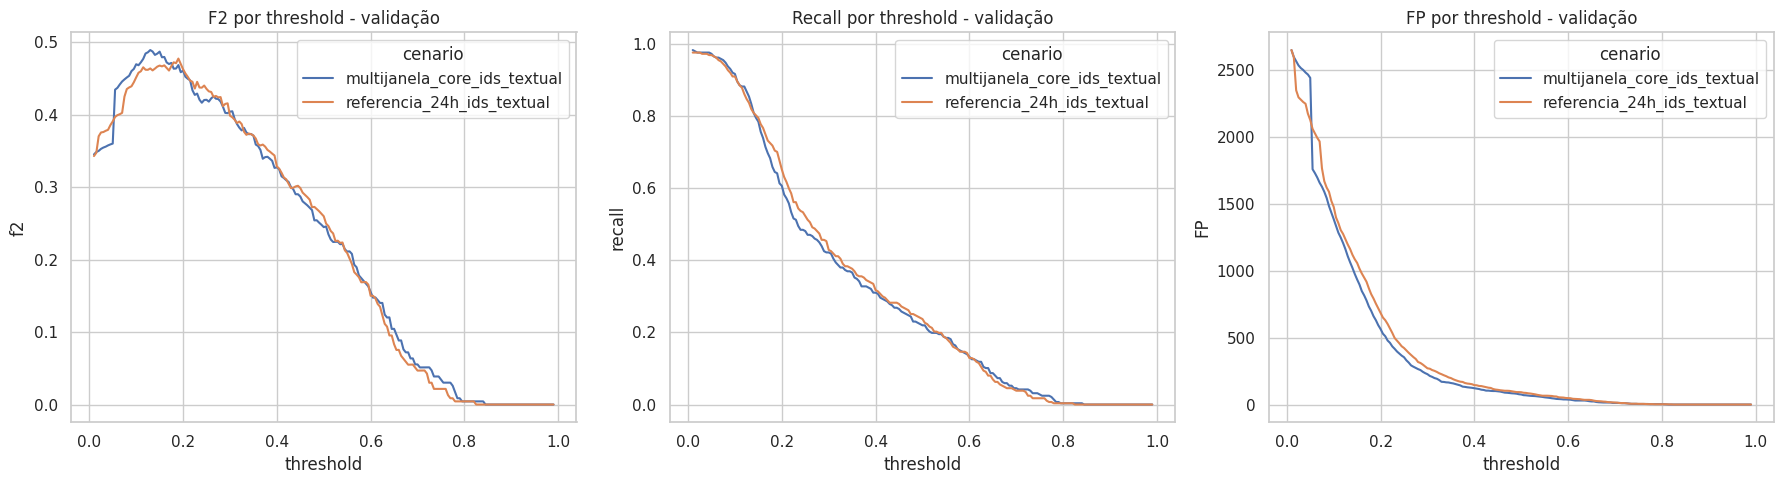

In [9]:
def metric_at_threshold(df, threshold):
    y_true = df["target"].astype("int8")
    prob = df["probabilidade"].to_numpy()
    pred = (prob >= threshold).astype("int8")
    return {
        "threshold": threshold,
        "amostras": len(df),
        "positivas": int(y_true.sum()),
        "pr_auc": average_precision_score(y_true, prob),
        "roc_auc": roc_auc_score(y_true, prob),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "predicoes_positivas": int(pred.sum()),
        "TP": int(((y_true == 1) & (pred == 1)).sum()),
        "FP": int(((y_true == 0) & (pred == 1)).sum()),
        "FN": int(((y_true == 1) & (pred == 0)).sum()),
        "TN": int(((y_true == 0) & (pred == 0)).sum()),
    }

threshold_rows = []
for (cenario, split), part in predictions.groupby(["cenario", "split"]):
    for threshold in THRESHOLD_GRID:
        row = metric_at_threshold(part, threshold)
        row["cenario"] = cenario
        row["split"] = split
        threshold_rows.append(row)
threshold_metrics = pd.DataFrame(threshold_rows)

technical_choice = (
    threshold_metrics[threshold_metrics["split"] == "validacao"]
    .sort_values(["cenario", "f2", "precision", "threshold"], ascending=[True, False, False, False])
    .groupby("cenario")
    .head(1)
    [["cenario", "threshold"]]
    .rename(columns={"threshold": "threshold_f2_validacao"})
)

technical_test = threshold_metrics[threshold_metrics["split"] == "teste"].merge(
    technical_choice,
    left_on=["cenario", "threshold"],
    right_on=["cenario", "threshold_f2_validacao"],
    how="inner",
)

display(technical_choice)
display(technical_test[[
    "cenario", "threshold", "pr_auc", "precision", "recall", "f2",
    "TP", "FP", "FN", "TN", "predicoes_positivas"
]])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
val_curves = threshold_metrics[threshold_metrics["split"] == "validacao"]
sns.lineplot(data=val_curves, x="threshold", y="f2", hue="cenario", ax=axes[0])
axes[0].set(title="F2 por threshold - validação")
sns.lineplot(data=val_curves, x="threshold", y="recall", hue="cenario", ax=axes[1])
axes[1].set(title="Recall por threshold - validação")
sns.lineplot(data=val_curves, x="threshold", y="FP", hue="cenario", ax=axes[2])
axes[2].set(title="FP por threshold - validação")
plt.tight_layout()
plt.show()

## 6. Valor esperado por cenário econômico

,cenario,cenario_custo,threshold_economico_validacao,valor_validacao
280,multijanela_core_ids_textual,base_empirico_manutencao_8h,0.425,2539400.0
678,referencia_24h_ids_textual,base_empirico_manutencao_8h,0.445,2137700.0


,cenario,cenario_custo,threshold,valor_incremental_total,TP,FP,FN,TN,predicoes_positivas
0,multijanela_core_ids_textual,base_empirico_manutencao_8h,0.425,2096000.0,80,111,205,2649,191
1,referencia_24h_ids_textual,base_empirico_manutencao_8h,0.445,1942800.0,84,123,201,2637,207


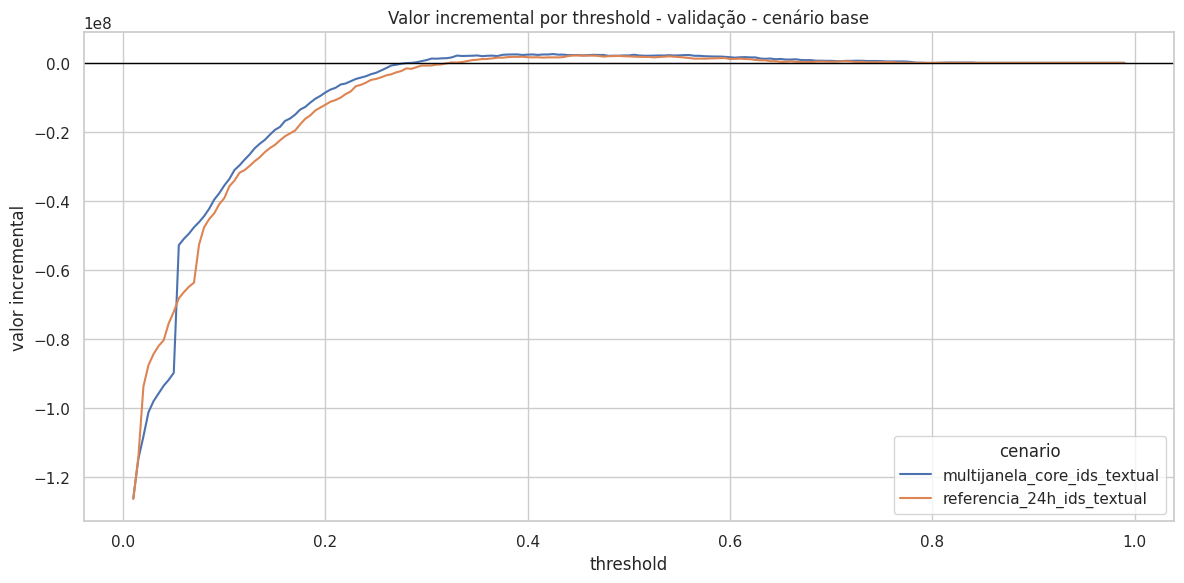

In [10]:
def normalize_tipo(value):
    if pd.isna(value):
        return "Indefinido"
    text = str(value)
    if "ESCAV" in text.upper():
        return "Escavadeira"
    return "Caminhao"

predictions["tipo_economico"] = predictions["Tipo"].map(normalize_tipo)

def economic_value_rows(pred_df, assumptions, threshold):
    scored = pred_df.copy()
    scored["predito"] = (scored["probabilidade"] >= threshold).astype("int8")
    scored["erro"] = np.select(
        [
            (scored["target"] == 1) & (scored["predito"] == 1),
            (scored["target"] == 0) & (scored["predito"] == 1),
            (scored["target"] == 1) & (scored["predito"] == 0),
            (scored["target"] == 0) & (scored["predito"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="indefinido",
    )
    scored = scored.merge(assumptions.rename(columns={"Tipo": "tipo_economico"}), how="left", on="tipo_economico")
    if scored["cenario_custo"].isna().any():
        missing = scored.loc[scored["cenario_custo"].isna(), "tipo_economico"].unique()
        raise ValueError(f"Sem premissa econômica para tipos: {missing}")

    no_action_cost = scored["p_acao_confirmada"] * (
        scored["custo_manutencao_corretiva"]
        + scored["impacto_operacional_hora"] * scored["horas_parada_corretiva"]
    )
    tp_action_cost = scored["custo_intervencao_preditiva"] + scored["p_acao_confirmada"] * (
        scored["impacto_operacional_hora"] * scored["horas_parada_preditiva"]
    )
    fp_action_cost = scored["custo_intervencao_preditiva"] + (
        scored["impacto_operacional_hora"] * scored["horas_parada_preditiva"]
    )

    scored["custo_incremental_vs_sem_modelo"] = np.select(
        [
            scored["erro"] == "TP",
            scored["erro"] == "FP",
            scored["erro"] == "FN",
            scored["erro"] == "TN",
        ],
        [
            tp_action_cost - no_action_cost,
            fp_action_cost,
            0.0,
            0.0,
        ],
        default=np.nan,
    )
    scored["valor_incremental_vs_sem_modelo"] = -scored["custo_incremental_vs_sem_modelo"]
    return scored

economic_rows = []
for (cenario_modelo, split), part in predictions.groupby(["cenario", "split"]):
    for threshold in THRESHOLD_GRID:
        scored = economic_value_rows(part, economic_base, threshold)
        out = (
            scored.groupby(["cenario_custo"], dropna=False)
            .agg(
                valor_incremental_total=("valor_incremental_vs_sem_modelo", "sum"),
                custo_incremental_total=("custo_incremental_vs_sem_modelo", "sum"),
                amostras=("target", "size"),
                positivos=("target", "sum"),
                predicoes_positivas=("predito", "sum"),
                TP=("erro", lambda x: (x == "TP").sum()),
                FP=("erro", lambda x: (x == "FP").sum()),
                FN=("erro", lambda x: (x == "FN").sum()),
                TN=("erro", lambda x: (x == "TN").sum()),
            )
            .reset_index()
        )
        out["cenario"] = cenario_modelo
        out["split"] = split
        out["threshold"] = threshold
        economic_rows.append(out)
economic_threshold_base = pd.concat(economic_rows, ignore_index=True)

economic_choice = (
    economic_threshold_base[economic_threshold_base["split"] == "validacao"]
    .sort_values(["cenario", "valor_incremental_total", "threshold"], ascending=[True, False, False])
    .groupby("cenario")
    .head(1)
    [["cenario", "cenario_custo", "threshold", "valor_incremental_total"]]
    .rename(columns={
        "threshold": "threshold_economico_validacao",
        "valor_incremental_total": "valor_validacao",
    })
)

economic_test = economic_threshold_base[economic_threshold_base["split"] == "teste"].merge(
    economic_choice,
    left_on=["cenario", "cenario_custo", "threshold"],
    right_on=["cenario", "cenario_custo", "threshold_economico_validacao"],
    how="inner",
)

display(economic_choice)
display(economic_test[[
    "cenario", "cenario_custo", "threshold", "valor_incremental_total",
    "TP", "FP", "FN", "TN", "predicoes_positivas"
]])

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = economic_threshold_base[economic_threshold_base["split"] == "validacao"]
sns.lineplot(data=plot_df, x="threshold", y="valor_incremental_total", hue="cenario", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Valor incremental por threshold - validação - cenário base", ylabel="valor incremental")
plt.tight_layout()
plt.show()

## 7. Sensibilidade econômica

In [11]:
sensitivity_rows = []
for (cenario_modelo, split), part in predictions.groupby(["cenario", "split"]):
    if split != "validacao":
        continue
    for threshold in THRESHOLD_GRID:
        for cenario_custo, assumptions in economic_sensitivity.groupby("cenario_custo"):
            scored = economic_value_rows(part, assumptions, threshold)
            sensitivity_rows.append({
                "cenario": cenario_modelo,
                "split": split,
                "cenario_custo": cenario_custo,
                "threshold": threshold,
                "valor_incremental_total": scored["valor_incremental_vs_sem_modelo"].sum(),
                "predicoes_positivas": int((scored["predito"] == 1).sum()),
                "TP": int((scored["erro"] == "TP").sum()),
                "FP": int((scored["erro"] == "FP").sum()),
                "FN": int((scored["erro"] == "FN").sum()),
                "TN": int((scored["erro"] == "TN").sum()),
            })
sensitivity_valid = pd.DataFrame(sensitivity_rows)

sensitivity_winners = (
    sensitivity_valid
    .sort_values(["cenario_custo", "cenario", "valor_incremental_total", "threshold"], ascending=[True, True, False, False])
    .groupby(["cenario_custo", "cenario"])
    .head(1)
    .reset_index(drop=True)
)

display(sensitivity_winners.sort_values(["cenario_custo", "valor_incremental_total"], ascending=[True, False]).head(40))

winner_by_cost = (
    sensitivity_winners
    .sort_values(["cenario_custo", "valor_incremental_total"], ascending=[True, False])
    .groupby("cenario_custo")
    .head(1)
    .reset_index(drop=True)
)
display(winner_by_cost)

winner_counts = winner_by_cost["cenario"].value_counts().reset_index()
winner_counts.columns = ["cenario", "qtde_cenarios_custo_vencedor"]
display(winner_counts)

,cenario,split,cenario_custo,threshold,valor_incremental_total,predicoes_positivas,TP,FP,FN,TN
0,multijanela_core_ids_textual,validacao,impacto_x0.5_p0.05,0.990,0.0,0,0,0,287,2863
1,referencia_24h_ids_textual,validacao,impacto_x0.5_p0.05,0.990,0.0,0,0,0,287,2863
2,multijanela_core_ids_textual,validacao,impacto_x0.5_p0.1,0.990,0.0,0,0,0,287,2863
3,referencia_24h_ids_textual,validacao,impacto_x0.5_p0.1,0.990,0.0,0,0,0,287,2863
4,multijanela_core_ids_textual,validacao,impacto_x0.5_p0.2,0.840,4000.0,1,1,0,286,2863
5,referencia_24h_ids_textual,validacao,impacto_x0.5_p0.2,0.990,0.0,0,0,0,287,2863
6,multijanela_core_ids_textual,validacao,impacto_x0.5_p0.4,0.750,44000.0,12,8,4,279,2859
7,referencia_24h_ids_textual,validacao,impacto_x0.5_p0.4,0.990,0.0,0,0,0,287,2863
8,multijanela_core_ids_textual,validacao,impacto_x1_p0.05,0.990,0.0,0,0,0,287,2863
9,referencia_24h_ids_textual,validacao,impacto_x1_p0.05,0.990,0.0,0,0,0,287,2863


,cenario,split,cenario_custo,threshold,valor_incremental_total,predicoes_positivas,TP,FP,FN,TN
0,multijanela_core_ids_textual,validacao,impacto_x0.5_p0.05,0.990,0.0,0,0,0,287,2863
1,multijanela_core_ids_textual,validacao,impacto_x0.5_p0.1,0.990,0.0,0,0,0,287,2863
2,multijanela_core_ids_textual,validacao,impacto_x0.5_p0.2,0.840,4000.0,1,1,0,286,2863
3,multijanela_core_ids_textual,validacao,impacto_x0.5_p0.4,0.750,44000.0,12,8,4,279,2859
4,multijanela_core_ids_textual,validacao,impacto_x1_p0.05,0.990,0.0,0,0,0,287,2863
5,multijanela_core_ids_textual,validacao,impacto_x1_p0.1,0.840,4000.0,1,1,0,286,2863
6,multijanela_core_ids_textual,validacao,impacto_x1_p0.2,0.840,18000.0,1,1,0,286,2863
7,multijanela_core_ids_textual,validacao,impacto_x1_p0.4,0.615,410000.0,65,35,30,252,2833
8,multijanela_core_ids_textual,validacao,impacto_x2_p0.05,0.840,4000.0,1,1,0,286,2863
9,multijanela_core_ids_textual,validacao,impacto_x2_p0.1,0.840,18000.0,1,1,0,286,2863


,cenario,qtde_cenarios_custo_vencedor
0,multijanela_core_ids_textual,12


## 8. Aplicação no teste dos thresholds escolhidos na validação

In [12]:
chosen_thresholds = pd.concat([
    technical_choice.assign(tipo_escolha="max_f2_validacao").rename(columns={"threshold_f2_validacao": "threshold"})[
        ["cenario", "tipo_escolha", "threshold"]
    ],
    economic_choice.assign(tipo_escolha="max_valor_base_validacao").rename(columns={"threshold_economico_validacao": "threshold"})[
        ["cenario", "tipo_escolha", "threshold"]
    ],
]).drop_duplicates()

test_rows = []
test_predictions_chosen = []
for _, choice in chosen_thresholds.iterrows():
    part = predictions[(predictions["cenario"] == choice["cenario"]) & (predictions["split"] == "teste")].copy()
    metrics = metric_at_threshold(part, float(choice["threshold"]))
    metrics["cenario"] = choice["cenario"]
    metrics["tipo_escolha"] = choice["tipo_escolha"]
    test_rows.append(metrics)
    scored = economic_value_rows(part, economic_base, float(choice["threshold"]))
    scored["tipo_escolha"] = choice["tipo_escolha"]
    test_predictions_chosen.append(scored)

chosen_test_metrics = pd.DataFrame(test_rows)
chosen_test_predictions = pd.concat(test_predictions_chosen, ignore_index=True)

economic_test_summary = (
    chosen_test_predictions
    .groupby(["cenario", "tipo_escolha", "cenario_custo"], dropna=False)
    .agg(valor_incremental_total=("valor_incremental_vs_sem_modelo", "sum"))
    .reset_index()
)

display(chosen_test_metrics[[
    "cenario", "tipo_escolha", "threshold", "precision", "recall", "f2",
    "TP", "FP", "FN", "TN", "predicoes_positivas"
]])
display(economic_test_summary)

,cenario,tipo_escolha,threshold,precision,recall,f2,TP,FP,FN,TN,predicoes_positivas
0,multijanela_core_ids_textual,max_f2_validacao,0.130,0.187688,0.877193,0.505663,250,1082,35,1678,1332
1,referencia_24h_ids_textual,max_f2_validacao,0.190,0.226580,0.729825,0.505345,208,710,77,2050,918
2,multijanela_core_ids_textual,max_valor_base_validacao,0.425,0.418848,0.280702,0.300526,80,111,205,2649,191
3,referencia_24h_ids_textual,max_valor_base_validacao,0.445,0.405797,0.294737,0.311804,84,123,201,2637,207


,cenario,tipo_escolha,cenario_custo,valor_incremental_total
0,multijanela_core_ids_textual,max_f2_validacao,base_empirico_manutencao_8h,-23225000.0
1,multijanela_core_ids_textual,max_valor_base_validacao,base_empirico_manutencao_8h,2096000.0
2,referencia_24h_ids_textual,max_f2_validacao,base_empirico_manutencao_8h,-11406400.0
3,referencia_24h_ids_textual,max_valor_base_validacao,base_empirico_manutencao_8h,1942800.0


## 9. Recortes obrigatórios

In [13]:
def summarize_group(df, group_cols):
    out = (
        df.groupby(group_cols, dropna=False)
        .agg(
            amostras=("target", "size"),
            positivos_reais=("target", "sum"),
            positivos_previstos=("predito", "sum"),
            TP=("erro", lambda x: (x == "TP").sum()),
            FP=("erro", lambda x: (x == "FP").sum()),
            FN=("erro", lambda x: (x == "FN").sum()),
            TN=("erro", lambda x: (x == "TN").sum()),
            valor_incremental=("valor_incremental_vs_sem_modelo", "sum"),
            prob_media=("probabilidade", "mean"),
            prob_p90=("probabilidade", lambda x: x.quantile(.90)),
        )
        .reset_index()
    )
    out["precision"] = out["TP"] / (out["TP"] + out["FP"]).replace(0, np.nan)
    out["recall"] = out["TP"] / (out["TP"] + out["FN"]).replace(0, np.nan)
    out["taxa_fp"] = out["FP"] / (out["FP"] + out["TN"]).replace(0, np.nan)
    out["prevalencia"] = out["positivos_reais"] / out["amostras"]
    return out

display(summarize_group(chosen_test_predictions, ["cenario", "tipo_escolha", "tipo_economico"]))

tag_summary = summarize_group(chosen_test_predictions, ["cenario", "tipo_escolha", "TAG", "Tipo", "Tag_Frota"])
print("TAGs com mais FP:")
display(tag_summary.sort_values(["cenario", "tipo_escolha", "FP"], ascending=[True, True, False]).groupby(["cenario", "tipo_escolha"]).head(12))
print("TAGs com mais FN:")
display(tag_summary.sort_values(["cenario", "tipo_escolha", "FN"], ascending=[True, True, False]).groupby(["cenario", "tipo_escolha"]).head(12))

for (cenario, tipo_escolha), part in chosen_test_predictions.groupby(["cenario", "tipo_escolha"]):
    print(f"\n=== {cenario} | {tipo_escolha} ===")
    print("FNs de menor probabilidade:")
    display(part[part["erro"] == "FN"].sort_values("probabilidade").head(15))
    print("FPs de maior probabilidade:")
    display(part[part["erro"] == "FP"].sort_values("probabilidade", ascending=False).head(15))

,cenario,tipo_escolha,tipo_economico,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,valor_incremental,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
0,multijanela_core_ids_textual,max_f2_validacao,Caminhao,2610,283,1330,250,1080,33,1247,-22775000.0,0.173824,0.360959,0.187970,0.883392,0.464117,0.108429
1,multijanela_core_ids_textual,max_f2_validacao,Escavadeira,435,2,2,0,2,2,431,-450000.0,0.016462,0.049427,0.000000,0.000000,0.004619,0.004598
2,multijanela_core_ids_textual,max_valor_base_validacao,Caminhao,2610,283,191,80,111,203,2216,2096000.0,0.173824,0.360959,0.418848,0.282686,0.047701,0.108429
3,multijanela_core_ids_textual,max_valor_base_validacao,Escavadeira,435,2,0,0,0,2,433,0.0,0.016462,0.049427,NaN,0.000000,0.000000,0.004598
4,referencia_24h_ids_textual,max_f2_validacao,Caminhao,2610,283,918,208,710,75,1617,-11406400.0,0.183102,0.395616,0.226580,0.734982,0.305114,0.108429
5,referencia_24h_ids_textual,max_f2_validacao,Escavadeira,435,2,0,0,0,2,433,0.0,0.015545,0.036503,NaN,0.000000,0.000000,0.004598
6,referencia_24h_ids_textual,max_valor_base_validacao,Caminhao,2610,283,207,84,123,199,2204,1942800.0,0.183102,0.395616,0.405797,0.296820,0.052858,0.108429
7,referencia_24h_ids_textual,max_valor_base_validacao,Escavadeira,435,2,0,0,0,2,433,0.0,0.015545,0.036503,NaN,0.000000,0.000000,0.004598


TAGs com mais FP:


,cenario,tipo_escolha,TAG,Tipo,Tag_Frota,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,valor_incremental,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
5,multijanela_core_ids_textual,max_f2_validacao,CA65792,Caminhao,793-D 2S,87,12,84,10,74,2,1,-2143000.0,0.305891,0.459308,0.119048,0.833333,0.986667,0.137931
1,multijanela_core_ids_textual,max_f2_validacao,CA5927,Caminhao,793-D 5S,87,14,71,13,58,1,15,-1257900.0,0.252767,0.371443,0.183099,0.928571,0.794521,0.160920
21,multijanela_core_ids_textual,max_f2_validacao,CA65929,Caminhao,793-D 5S,87,1,58,1,57,0,29,-2198300.0,0.160665,0.246947,0.017241,1.000000,0.662791,0.011494
16,multijanela_core_ids_textual,max_f2_validacao,CA65924,Caminhao,793-D 4S,87,10,62,7,55,3,22,-1628100.0,0.220060,0.461877,0.112903,0.700000,0.714286,0.114943
25,multijanela_core_ids_textual,max_f2_validacao,CA65933,Caminhao,793-D 5S,87,20,74,20,54,0,13,-526000.0,0.232516,0.420732,0.270270,1.000000,0.805970,0.229885
28,multijanela_core_ids_textual,max_f2_validacao,CA65936,Caminhao,793-D 5S,87,23,74,20,54,3,10,-526000.0,0.196312,0.275250,0.270270,0.869565,0.843750,0.264368
22,multijanela_core_ids_textual,max_f2_validacao,CA65930,Caminhao,793-D 5S,87,6,58,5,53,1,28,-1711500.0,0.171251,0.261634,0.086207,0.833333,0.654321,0.068966
11,multijanela_core_ids_textual,max_f2_validacao,CA65916,Caminhao,793-D 4S,87,1,53,1,52,0,34,-1998300.0,0.162781,0.251302,0.018868,1.000000,0.604651,0.011494
26,multijanela_core_ids_textual,max_f2_validacao,CA65934,Caminhao,793-D 5S,87,2,54,2,52,0,33,-1916600.0,0.160965,0.239551,0.037037,1.000000,0.611765,0.022989
27,multijanela_core_ids_textual,max_f2_validacao,CA65935,Caminhao,793-D 5S,87,16,64,13,51,3,20,-977900.0,0.235758,0.494250,0.203125,0.812500,0.718310,0.183908


TAGs com mais FN:


,cenario,tipo_escolha,TAG,Tipo,Tag_Frota,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,valor_incremental,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
16,multijanela_core_ids_textual,max_f2_validacao,CA65924,Caminhao,793-D 4S,87,10,62,7,55,3,22,-1628100.0,0.220060,0.461877,0.112903,0.700000,0.714286,0.114943
24,multijanela_core_ids_textual,max_f2_validacao,CA65932,Caminhao,793-D 5S,87,9,53,6,47,3,31,-1389800.0,0.271327,0.616193,0.113208,0.666667,0.602564,0.103448
27,multijanela_core_ids_textual,max_f2_validacao,CA65935,Caminhao,793-D 5S,87,16,64,13,51,3,20,-977900.0,0.235758,0.494250,0.203125,0.812500,0.718310,0.183908
28,multijanela_core_ids_textual,max_f2_validacao,CA65936,Caminhao,793-D 5S,87,23,74,20,54,3,10,-526000.0,0.196312,0.275250,0.270270,0.869565,0.843750,0.264368
29,multijanela_core_ids_textual,max_f2_validacao,CA65937,Caminhao,793-D 5S,87,8,35,5,30,3,49,-791500.0,0.132723,0.225155,0.142857,0.625000,0.379747,0.091954
2,multijanela_core_ids_textual,max_f2_validacao,CA65789,Caminhao,793-D 2S,87,3,21,1,20,2,64,-718300.0,0.104898,0.188891,0.047619,0.333333,0.238095,0.034483
5,multijanela_core_ids_textual,max_f2_validacao,CA65792,Caminhao,793-D 2S,87,12,84,10,74,2,1,-2143000.0,0.305891,0.459308,0.119048,0.833333,0.986667,0.137931
13,multijanela_core_ids_textual,max_f2_validacao,CA65921,Caminhao,793-D 4S,87,15,58,13,45,2,27,-737900.0,0.247963,0.512287,0.224138,0.866667,0.625000,0.172414
18,multijanela_core_ids_textual,max_f2_validacao,CA65926,Caminhao,793-D 4S,87,53,82,51,31,2,3,2926700.0,0.419820,0.729809,0.621951,0.962264,0.911765,0.609195
0,multijanela_core_ids_textual,max_f2_validacao,CA5926,Caminhao,793-D 5S,87,11,49,10,39,1,37,-743000.0,0.194248,0.390000,0.204082,0.909091,0.513158,0.126437


...

,sample_id,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,target,cenario,split,probabilidade,features,tempo_treino_s,tipo_economico,predito,erro,cenario_custo,p_acao_confirmada,custo_intervencao_preditiva,custo_manutencao_corretiva,impacto_operacional_hora,horas_parada_corretiva,horas_parada_preditiva,nivel_confianca,base_premissa,custo_incremental_vs_sem_modelo,valor_incremental_vs_sem_modelo,tipo_escolha
4353,8051,CA65921,Caminhao,793-D 4S,2025-06-13 08:00:00,2025-06-14 08:00:00,2025-06-14 16:00:00,0,referencia_24h_ids_textual,teste,0.783283,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao
6021,1079,CA5927,Caminhao,793-D 5S,2025-06-29 08:00:00,2025-06-30 08:00:00,2025-06-30 16:00:00,0,referencia_24h_ids_textual,teste,0.771417,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao
4498,3735,CA65926,Caminhao,793-D 4S,2025-06-14 16:00:00,2025-06-15 16:00:00,2025-06-16 00:00:00,0,referencia_24h_ids_textual,teste,0.760531,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao
4113,3724,CA65926,Caminhao,793-D 4S,2025-06-11 00:00:00,2025-06-12 00:00:00,2025-06-12 08:00:00,0,referencia_24h_ids_textual,teste,0.752694,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao
3944,5879,CA65932,Caminhao,793-D 5S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,0,referencia_24h_ids_textual,teste,0.743357,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao
4014,5881,CA65932,Caminhao,793-D 5S,2025-06-10 00:00:00,2025-06-11 00:00:00,2025-06-11 08:00:00,0,referencia_24h_ids_textual,teste,0.716259,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao
3335,13962,CA65915,Caminhao,793-D 4S,2025-06-03 16:00:00,2025-06-04 16:00:00,2025-06-05 00:00:00,0,referencia_24h_ids_textual,teste,0.702372,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao
3933,8039,CA65921,Caminhao,793-D 4S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,0,referencia_24h_ids_textual,teste,0.688405,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao
3492,10726,CA65935,Caminhao,793-D 5S,2025-06-05 00:00:00,2025-06-06 00:00:00,2025-06-06 08:00:00,0,referencia_24h_ids_textual,teste,0.678637,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao
3909,5878,CA65932,Caminhao,793-D 5S,2025-06-09 00:00:00,2025-06-10 00:00:00,2025-06-10 08:00:00,0,referencia_24h_ids_textual,teste,0.671479,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_f2_validacao



=== referencia_24h_ids_textual | max_valor_base_validacao ===
FNs de menor probabilidade:


,sample_id,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,target,cenario,split,probabilidade,features,tempo_treino_s,tipo_economico,predito,erro,cenario_custo,p_acao_confirmada,custo_intervencao_preditiva,custo_manutencao_corretiva,impacto_operacional_hora,horas_parada_corretiva,horas_parada_preditiva,nivel_confianca,base_premissa,custo_incremental_vs_sem_modelo,valor_incremental_vs_sem_modelo,tipo_escolha
11790,16729,PE3795,Escavadeira,LeTourneau L 1850,2025-06-26 00:00:00,2025-06-27 00:00:00,2025-06-27 08:00:00,1,referencia_24h_ids_textual,teste,0.000000,416,2.3,Escavadeira,0,FN,base_empirico_manutencao_8h,0.200,25000.0,150000.0,100000.0,8.0,2.0,baixa,p conservador por poucos episódios Dont Go; cu...,0.0,-0.0,max_valor_base_validacao
9202,12335,PE3797,Escavadeira,LeTourneau L 1850,2025-06-01 08:00:00,2025-06-02 08:00:00,2025-06-02 16:00:00,1,referencia_24h_ids_textual,teste,0.008041,416,2.3,Escavadeira,0,FN,base_empirico_manutencao_8h,0.200,25000.0,150000.0,100000.0,8.0,2.0,baixa,p conservador por poucos episódios Dont Go; cu...,0.0,-0.0,max_valor_base_validacao
11884,4312,CA65927,Caminhao,793-D 5S,2025-06-27 00:00:00,2025-06-28 00:00:00,2025-06-28 08:00:00,1,referencia_24h_ids_textual,teste,0.044682,416,2.3,Caminhao,0,FN,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,0.0,-0.0,max_valor_base_validacao
12081,15118,CA65793,Caminhao,793-D 2S,2025-06-29 00:00:00,2025-06-30 00:00:00,2025-06-30 08:00:00,1,referencia_24h_ids_textual,teste,0.051178,416,2.3,Caminhao,0,FN,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,0.0,-0.0,max_valor_base_validacao
9215,13956,CA65915,Caminhao,793-D 4S,2025-06-01 16:00:00,2025-06-02 16:00:00,2025-06-03 00:00:00,1,referencia_24h_ids_textual,teste,0.058024,416,2.3,Caminhao,0,FN,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,0.0,-0.0,max_valor_base_validacao
10097,9121,CA65925,Caminhao,793-D 4S,2025-06-10 00:00:00,2025-06-11 00:00:00,2025-06-11 08:00:00,1,referencia_24h_ids_textual,teste,0.065452,416,2.3,Caminhao,0,FN,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,0.0,-0.0,max_valor_base_validacao
10365,7509,CA65792,Caminhao,793-D 2S,2025-06-12 16:00:00,2025-06-13 16:00:00,2025-06-14 00:00:00,1,referencia_24h_ids_textual,teste,0.067299,416,2.3,Caminhao,0,FN,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,0.0,-0.0,max_valor_base_validacao
10010,13439,CA5926,Caminhao,793-D 5S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,1,referencia_24h_ids_textual,teste,0.074674,416,2.3,Caminhao,0,FN,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,0.0,-0.0,max_valor_base_validacao
9223,3696,CA65926,Caminhao,793-D 4S,2025-06-01 16:00:00,2025-06-02 16:00:00,2025-06-03 00:00:00,1,referencia_24h_ids_textual,teste,0.077604,416,2.3,Caminhao,0,FN,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,0.0,-0.0,max_valor_base_validacao
11682,10786,CA65935,Caminhao,793-D 5S,2025-06-25 00:00:00,2025-06-26 00:00:00,2025-06-26 08:00:00,1,referencia_24h_ids_textual,teste,0.078474,416,2.3,Caminhao,0,FN,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,0.0,-0.0,max_valor_base_validacao


FPs de maior probabilidade:


,sample_id,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,target,cenario,split,probabilidade,features,tempo_treino_s,tipo_economico,predito,erro,cenario_custo,p_acao_confirmada,custo_intervencao_preditiva,custo_manutencao_corretiva,impacto_operacional_hora,horas_parada_corretiva,horas_parada_preditiva,nivel_confianca,base_premissa,custo_incremental_vs_sem_modelo,valor_incremental_vs_sem_modelo,tipo_escolha
10443,8051,CA65921,Caminhao,793-D 4S,2025-06-13 08:00:00,2025-06-14 08:00:00,2025-06-14 16:00:00,0,referencia_24h_ids_textual,teste,0.783283,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao
12111,1079,CA5927,Caminhao,793-D 5S,2025-06-29 08:00:00,2025-06-30 08:00:00,2025-06-30 16:00:00,0,referencia_24h_ids_textual,teste,0.771417,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao
10588,3735,CA65926,Caminhao,793-D 4S,2025-06-14 16:00:00,2025-06-15 16:00:00,2025-06-16 00:00:00,0,referencia_24h_ids_textual,teste,0.760531,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao
10203,3724,CA65926,Caminhao,793-D 4S,2025-06-11 00:00:00,2025-06-12 00:00:00,2025-06-12 08:00:00,0,referencia_24h_ids_textual,teste,0.752694,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao
10034,5879,CA65932,Caminhao,793-D 5S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,0,referencia_24h_ids_textual,teste,0.743357,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao
10104,5881,CA65932,Caminhao,793-D 5S,2025-06-10 00:00:00,2025-06-11 00:00:00,2025-06-11 08:00:00,0,referencia_24h_ids_textual,teste,0.716259,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao
9425,13962,CA65915,Caminhao,793-D 4S,2025-06-03 16:00:00,2025-06-04 16:00:00,2025-06-05 00:00:00,0,referencia_24h_ids_textual,teste,0.702372,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao
10023,8039,CA65921,Caminhao,793-D 4S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,0,referencia_24h_ids_textual,teste,0.688405,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao
9582,10726,CA65935,Caminhao,793-D 5S,2025-06-05 00:00:00,2025-06-06 00:00:00,2025-06-06 08:00:00,0,referencia_24h_ids_textual,teste,0.678637,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao
9999,5878,CA65932,Caminhao,793-D 5S,2025-06-09 00:00:00,2025-06-10 00:00:00,2025-06-10 08:00:00,0,referencia_24h_ids_textual,teste,0.671479,416,2.3,Caminhao,1,FP,base_empirico_manutencao_8h,0.655,10000.0,50000.0,30000.0,4.0,1.0,media,p observado no treino: Dont Go -> Manutenção e...,40000.0,-40000.0,max_valor_base_validacao


## 10. Leitura auditada a registrar

Ao consolidar este notebook, registrar separadamente:

1. **Evidência técnica:** métricas e matrizes do threshold escolhido na validação.
2. **Evidência de sensibilidade:** em quais cenários econômicos a referência ou a multijanela vencem.
3. **Limite:** valores econômicos são externos; `p_acao_confirmada` é uma premissa necessária porque
   `Is_Dont_Go` não é falha confirmada.
4. **Decisão possível:** manter referência agregada se a multijanela só ganhar sob premissas agressivas
   ou com muitos FP; preservar multijanela se vencer em ampla faixa de custo e reduzir FN de forma
   operacionalmente defensável.